In [156]:
import pandas as pd

df = pd.read_csv("/content/customer_rfm data.csv")
df=df.dropna()

In [157]:
X = df[['recency', 'frequency', 'monetary']]

In [158]:
import numpy as np

X['recency'] = np.log1p(X['recency'])
X['frequency'] = np.log1p(X['frequency'])
X['monetary'] = np.log1p(X['monetary'])

/tmp/ipykernel_9490/2441183397.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['recency'] = np.log1p(X['recency'])
/tmp/ipykernel_9490/2441183397.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['frequency'] = np.log1p(X['frequency'])
/tmp/ipykernel_9490/2441183397.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

In [159]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

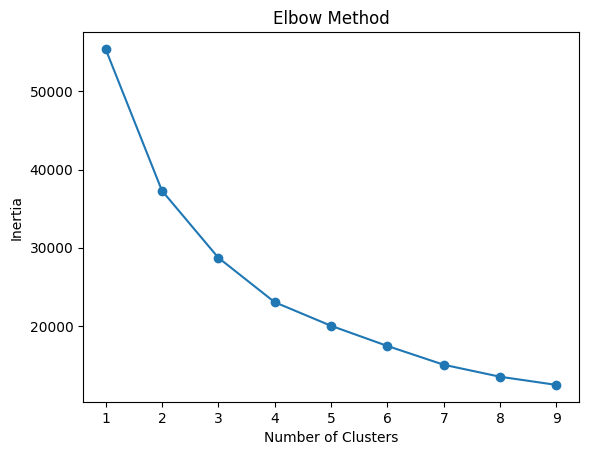

In [160]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [161]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(X_scaled)

In [162]:
cluster_summary = df.groupby('cluster')[['recency','frequency','monetary']].mean()
print(cluster_summary)

             recency   frequency  monetary
cluster                                   
0         245.241055   34.932916  3.173077
1          50.100030  212.523838  2.269916
2        3313.516274  155.193040  5.216066
3        2430.224883  290.523425  2.115305


In [163]:
def label_cluster(row):
    if row['frequency'] > df['frequency'].median() and row['monetary'] > df['monetary'].median():
        return 'High Value'
    elif row['recency'] > df['recency'].median():
        return 'At Risk'
    else:
        return 'Regular'

df['ml_segment'] = df.apply(label_cluster, axis=1)

In [164]:
df.to_csv("customer_ml_segments.csv", index=False)